# Optostim JSON → HDF5 and plots

This notebook parses MATLAB optostim logs, converts them to HDF5 using the shared helpers in `behavioral_analysis.processing.optostim`, and builds QC plots. Update paths below for OS4/OS5 sessions.


In [16]:
from pathlib import Path
from collections import Counter
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

repo_root = Path('..').resolve()
if str(repo_root / 'src') not in sys.path:
    sys.path.append(str(repo_root / 'src'))

from behavioral_analysis.processing.optostim import (
    convert_optostim_session,
    normalize_matlab_logs,
)
from behavioral_analysis.io.json_parser import parse_json_file
from behavioral_analysis.io.hdf5_writer import list_hdf5_contents
from behavioral_analysis.visualization import trial_visualizer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## Configure input/output paths
Set the sessions you want to process. The defaults point at the OS4/OS5 runs mentioned in chat.


In [32]:
from pathlib import Path

DATA_ROOT = Path('/groups/spruston/sprustonlab/mesoscope-data')
TARGET_DATE = '2025-12-19'
SUBJECTS = ('OS4', 'OS5')

session_paths = sorted(
    path
    for subject in SUBJECTS
    for path in DATA_ROOT.glob(
        f'{subject}/{TARGET_DATE.replace("-", "_")}/*/Log {subject} {TARGET_DATE} session *.json'
    )
    if path.is_file()
)
if not session_paths:
    raise FileNotFoundError(f'No sessions found for {TARGET_DATE} under {DATA_ROOT}')

output_dir = Path('outputs/optostim')
output_dir.mkdir(parents=True, exist_ok=True)

selected_index = 0  # 0 = OS4, 1 = OS5
json_path = session_paths[selected_index]
print('Found sessions:', *session_paths, sep='\n- ')
print(f'Selected session: {json_path}')


Found sessions:
- /groups/spruston/sprustonlab/mesoscope-data/OS4/2025_12_19/1/Log OS4 2025-12-19 session 1.json
- /groups/spruston/sprustonlab/mesoscope-data/OS5/2025_12_19/1/Log OS5 2025-12-19 session 1.json
Selected session: /groups/spruston/sprustonlab/mesoscope-data/OS4/2025_12_19/1/Log OS4 2025-12-19 session 1.json


In [34]:
session_paths

[PosixPath('/groups/spruston/sprustonlab/mesoscope-data/OS4/2025_12_19/1/Log OS4 2025-12-19 session 1.json'),
 PosixPath('/groups/spruston/sprustonlab/mesoscope-data/OS5/2025_12_19/1/Log OS5 2025-12-19 session 1.json')]

## Inspect raw events
Quick counts show the mix of event types and MATLAB actions. This uses the light parser to avoid loading everything into pandas unnecessarily.


In [35]:
events = parse_json_file(str(json_path), verbose=False)
counts = Counter(ev.get('msg', 'Unknown') for ev in events)
display(pd.DataFrame(counts.items(), columns=['event', 'count']).sort_values('count', ascending=False))

log_actions = Counter()
for ev in events:
    if ev.get('msg') != 'Log':
        continue
    msg = (ev.get('data') or {}).get('msg', {}) or {}
    if isinstance(msg, dict):
        log_actions[msg.get('action') or msg.get('event')] += 1
display(pd.DataFrame(log_actions.items(), columns=['action', 'count']).sort_values('count', ascending=False))


,event,count
3,Position,172713
2,Log,92224
1,Linear Controller Settings,1
0,Info,1


,action,count
2,Camera Frame,87758
1,LickDetected,3229
3,TrialStart,277
4,StimulusDelivered,277
6,TrialEnd,276
9,Reward Delivery,128
8,ImmediateHit,128
5,CorrectRejection,125
7,ImmediateFalseAlarm,22
0,ExternalStartReceived,1


## Convert the selected session
Runs the optostim-aware conversion for the currently selected JSON and writes an HDF5 in `outputs/optostim/`.


In [36]:
result = convert_optostim_session(json_path, output_dir, preloaded_events=events, verbose=True)
trials_df = result.dataframes['Trials']
lick_df = result.dataframes['Lick']
print(f"Saved to: {result.output_h5}")
print('Row counts:', result.summary)
trials_df.head()


Saving data to HDF5 file: outputs/optostim/Log OS4 2025-12-19 session 1_optostim.h5
  Saved Position data (172713 rows)
  Saved Trials data (277 rows)
  Saved Lick data (3244 rows)
  Saved Matlab_Action_Log data (92224 rows)
  Saved Manual_Reward data (128 rows)
  Saved metadata


/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['trial_type', 'outcome_raw', 'outcome_source', 'outcome'], dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['source', 'action', 'timestamp', 'trialType', 'outcome_x', 'rewarded',
       'type', 'withSound', 'outcome_y', 'trial_type'],
      dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as Py

Successfully saved all data to outputs/optostim/Log OS4 2025-12-19 session 1_optostim.h5 in 0.20 seconds
Saved to: outputs/optostim/Log OS4 2025-12-19 session 1_optostim.h5
Row counts: {'Position': 172713, 'Trials': 277, 'Lick': 3244, 'Matlab_Action_Log': 92224, 'Reward': 0, 'Manual_Reward': 128}


,trial_id,trial_number,trial_type,is_rewarding,start_time_ms,stim_time_ms,end_time_ms,trial_duration_ms,outcome_raw,outcome_source,...,num_licks_reward,corridor,planned_response_window_s,planned_consumption_s,planned_iti_s,planned_iti_sd_s,planned_response_plus_consumption_s,planned_iti_plus_0sd_s,iti_actual_s,iti_delta_from_planned_s
0,0,1,NoGo,False,10022.17,10662.77,13683.72,3661.55,CorrectRejection,raw,...,2,0,3.0,3.0,7.0,2.0,6.0,7.0,8.43271,1.43271
1,1,2,NoGo,False,22116.43,22763.43,23250.91,1134.48,FalseAlarm,raw,...,6,0,3.0,3.0,7.0,2.0,6.0,7.0,4.21401,-2.78599
2,2,3,Go,True,27464.92,28142.43,31218.56,3753.64,Hit,raw,...,15,0,3.0,3.0,7.0,2.0,6.0,7.0,3.09830,-3.90170
3,3,4,Go,True,34316.86,34955.72,38037.76,3720.90,Hit,raw,...,14,0,3.0,3.0,7.0,2.0,6.0,7.0,5.47040,-1.52960
4,4,5,Go,True,43508.16,44161.41,47378.41,3870.25,Hit,raw,...,15,0,3.0,3.0,7.0,2.0,6.0,7.0,7.80978,0.80978


## Trial duration vs JSON metadata
Plots observed trial durations and compares against planned timing (response + consumption, and planned ITI).


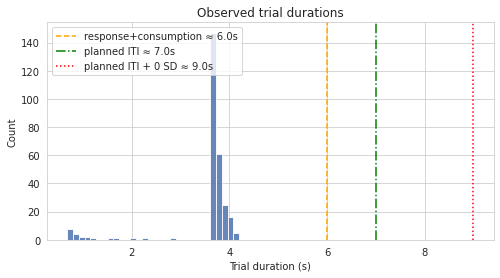

Observed duration stats (s):


count    276.000000
mean       3.540848
std        0.736283
min        0.682400
25%        3.661000
50%        3.671500
75%        3.797500
max        4.197600
Name: trial_duration_ms, dtype: float64

In [37]:
action_log = result.dataframes['Matlab_Action_Log']
cols = [c for c in ['responseWindow_s', 'consumptionPeriod_s', 'itiMean_s', 'itiSD_s', 'goProb', 'totalTrials'] if c in action_log.columns]
trial_start_meta = action_log[action_log['action'] == 'TrialStart'][cols].dropna(how='all') if cols else pd.DataFrame()

if trial_start_meta.empty:
    raise ValueError('No trial-start metadata found; cannot compare planned timings.')
if trials_df.empty:
    raise ValueError('Trials dataframe is empty; conversion likely failed.')

durations_s = trials_df['trial_duration_ms'] / 1000.0
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(durations_s.dropna(), bins=30, color='#4c72b0', edgecolor='white', alpha=0.85)
ax.set_xlabel('Trial duration (s)')
ax.set_ylabel('Count')
ax.set_title('Observed trial durations')

meta = trial_start_meta.median(numeric_only=True)
planned_window = meta.get('responseWindow_s', float('nan')) + meta.get('consumptionPeriod_s', float('nan'))
planned_iti = meta.get('itiMean_s', float('nan'))
planned_iti_sd = meta.get('itiSD_s', float('nan'))
if pd.notna(planned_window):
    ax.axvline(planned_window, color='orange', linestyle='--', label=f'response+consumption ≈ {planned_window:.1f}s')
if pd.notna(planned_iti):
    ax.axvline(planned_iti, color='green', linestyle='-.', label=f'planned ITI ≈ {planned_iti:.1f}s')
if pd.notna(planned_iti) and pd.notna(planned_iti_sd):
    ax.axvline(planned_iti + planned_iti_sd, color='red', linestyle=':', label=f'planned ITI + 0 SD ≈ {planned_iti + planned_iti_sd:.1f}s')
if ax.get_legend_handles_labels()[0]:
    ax.legend()

plt.show()

print('Observed duration stats (s):')
display(durations_s.describe())


## Inter-trial interval vs planned ITI
Compute actual ITIs from end→next start and compare to planned ITI and ITI+0 SD.


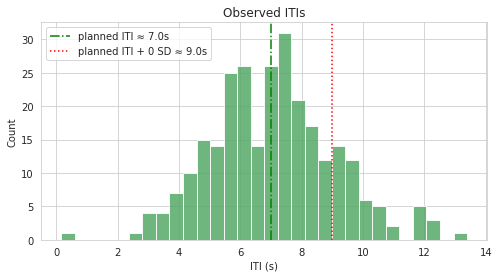

Observed ITI stats (s):


count    276.000000
mean       7.067256
std        2.025417
min        0.156000
25%        5.731622
50%        7.015500
75%        8.211650
max       13.390000
Name: iti_actual_s, dtype: float64

In [38]:
if trials_df.empty:
    raise ValueError('Trials dataframe is empty; cannot compute ITIs.')

iti_df = trials_df[['iti_actual_s', 'planned_iti_s', 'planned_iti_sd_s']].dropna(subset=['iti_actual_s'])
if iti_df.empty:
    raise ValueError('No ITI data available (need end_time_ms and next start).')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(iti_df['iti_actual_s'], bins=30, color='#55a868', edgecolor='white', alpha=0.85)
ax.set_xlabel('ITI (s)')
ax.set_ylabel('Count')
ax.set_title('Observed ITIs')

planned = iti_df[['planned_iti_s', 'planned_iti_sd_s']].median(numeric_only=True)
planned_iti = planned.get('planned_iti_s', float('nan'))
planned_iti_sd = planned.get('planned_iti_sd_s', float('nan'))
if pd.notna(planned_iti):
    ax.axvline(planned_iti, color='green', linestyle='-.', label=f'planned ITI ≈ {planned_iti:.1f}s')
if pd.notna(planned_iti) and pd.notna(planned_iti_sd):
    ax.axvline(planned_iti + planned_iti_sd, color='red', linestyle=':', label=f'planned ITI + 0 SD ≈ {planned_iti + planned_iti_sd:.1f}s')
if ax.get_legend_handles_labels()[0]:
    ax.legend()
plt.show()

print('Observed ITI stats (s):')
display(iti_df['iti_actual_s'].describe())


## (Optional) batch process all listed sessions
Set `run_all = True` to convert every path in `session_paths`.


In [39]:
output_dir = repo_root / 'outputs' / 'optostim'
output_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving to: {output_dir}")

Saving to: /groups/spruston/home/moharb/DELTA_Behavior/outputs/optostim


In [40]:
run_all = True
batch_results = []
if run_all:
    for path in session_paths:
        print(f'Converting {path.name} ...')
        batch_results.append(convert_optostim_session(path, output_dir, verbose=True))
    print('Done')


Converting Log OS4 2025-12-19 session 1.json ...
Saving data to HDF5 file: /groups/spruston/home/moharb/DELTA_Behavior/outputs/optostim/Log OS4 2025-12-19 session 1_optostim.h5
  Saved Position data (172713 rows)
  Saved Trials data (277 rows)
  Saved Lick data (3244 rows)
  Saved Matlab_Action_Log data (92224 rows)
  Saved Manual_Reward data (128 rows)
  Saved metadata
Successfully saved all data to /groups/spruston/home/moharb/DELTA_Behavior/outputs/optostim/Log OS4 2025-12-19 session 1_optostim.h5 in 0.19 seconds
Converting Log OS5 2025-12-19 session 1.json ...


/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['trial_type', 'outcome_raw', 'outcome_source', 'outcome'], dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['source', 'action', 'timestamp', 'trialType', 'outcome_x', 'rewarded',
       'type', 'withSound', 'outcome_y', 'trial_type'],
      dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as Py

Saving data to HDF5 file: /groups/spruston/home/moharb/DELTA_Behavior/outputs/optostim/Log OS5 2025-12-19 session 1_optostim.h5
  Saved Position data (166037 rows)
  Saved Trials data (261 rows)
  Saved Lick data (2082 rows)
  Saved Matlab_Action_Log data (86576 rows)
  Saved Manual_Reward data (128 rows)
  Saved metadata
Successfully saved all data to /groups/spruston/home/moharb/DELTA_Behavior/outputs/optostim/Log OS5 2025-12-19 session 1_optostim.h5 in 0.18 seconds
Done


/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block3_values] [items->Index(['source', 'action', 'timestamp', 'trialType', 'type', 'withSound',
       'outcome_x', 'rewarded', 'outcome_y', 'trial_type'],
      dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:52: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block1_values] [items->Index(['source', 'action', 'timestamp', 'trialType', 'type', 'withSound',
       'outcome', 'rewarded'],
      dtype='object')]

  store[f'events/{safe_event_type}'] = df
/groups/spruston/home/moharb/DELTA_Behavior/src/behavioral_analysis/io/hdf5_writer.py:74: Performan

## Quick plots
Uses the existing trial visualizer for outcome timelines plus a custom lick raster relative to the stimulus.


In [8]:
trials_df.query("outcome == 'Unknown'")

,trial_id,trial_number,trial_type,is_rewarding,start_time_ms,stim_time_ms,end_time_ms,trial_duration_ms,outcome_raw,outcome_source,...,num_licks_reward,corridor,planned_response_window_s,planned_consumption_s,planned_iti_s,planned_iti_sd_s,planned_response_plus_consumption_s,planned_iti_plus_0sd_s,iti_actual_s,iti_delta_from_planned_s


Trial outcomes timeline


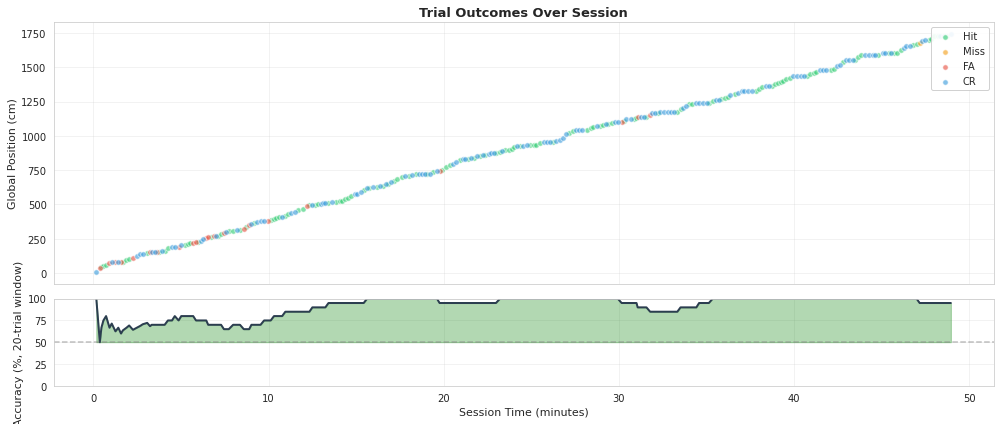

Performance summary


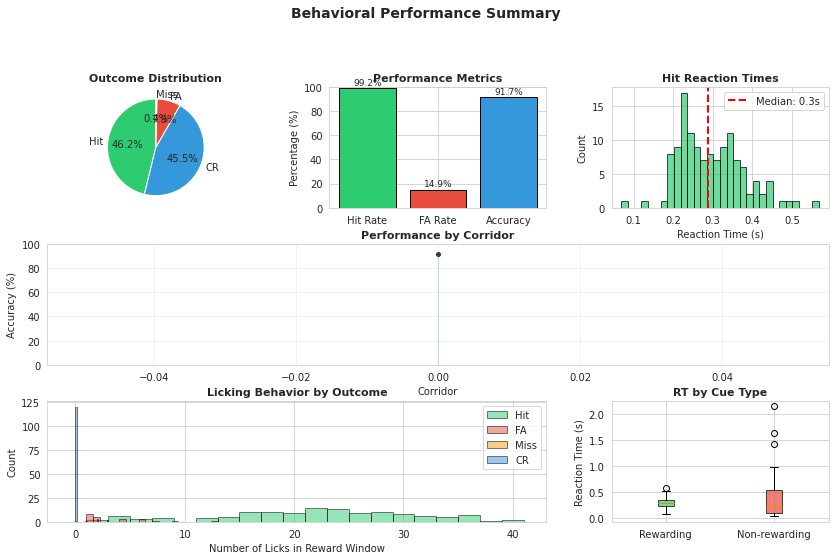

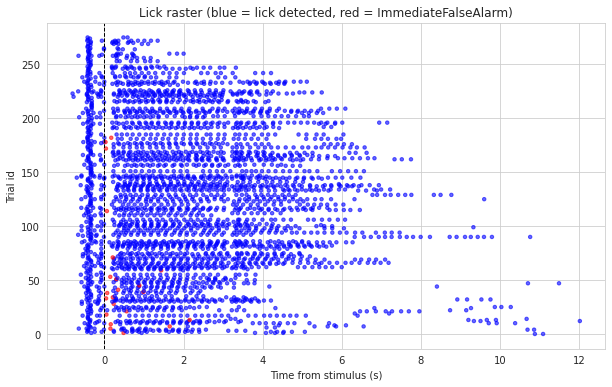

In [41]:
if trials_df.empty:
    raise ValueError('Trials dataframe is empty; cannot plot outcomes.')

print('Trial outcomes timeline')
fig1 = trial_visualizer.plot_trial_outcomes_timeline(trials_df)
plt.show()

print('Performance summary')
fig2 = trial_visualizer.plot_performance_summary(trials_df)
plt.show()

if lick_df.empty:
    raise ValueError('Lick table is empty; cannot plot lick raster.')
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(lick_df['time_from_stim_s'], lick_df['trial_id'],
           c=np.where(lick_df['is_immediate_false_alarm'], 'red', 'blue'),
           alpha=0.6, s=12, label='Licks')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Time from stimulus (s)')
ax.set_ylabel('Trial id')
ax.set_title('Lick raster (blue = lick detected, red = ImmediateFalseAlarm)')
plt.show()


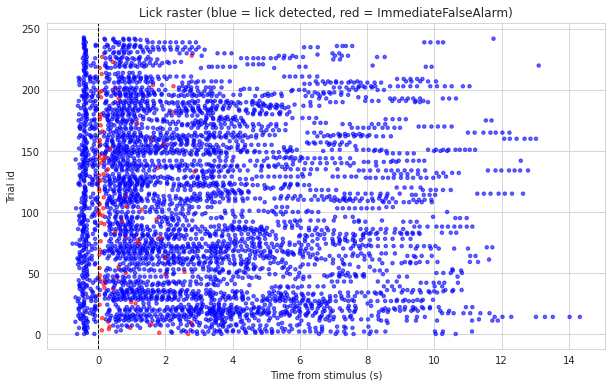

In [10]:
if lick_df.empty:
    raise ValueError('Lick table is empty; cannot plot lick raster.')
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(lick_df['time_from_stim_s'], lick_df['trial_id'],
           c=np.where(lick_df['is_immediate_false_alarm'], 'red', 'blue'),
           alpha=0.6, s=12, label='Licks')
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Time from stimulus (s)')
ax.set_ylabel('Trial id')
ax.set_title('Lick raster (blue = lick detected, red = ImmediateFalseAlarm)')
plt.show()

## Inspect saved HDF5 contents
Load the file to verify stored tables.


## Lick raster and probability (Go vs NoGo)
Uses time from trial start; fails if licks or trials are missing.


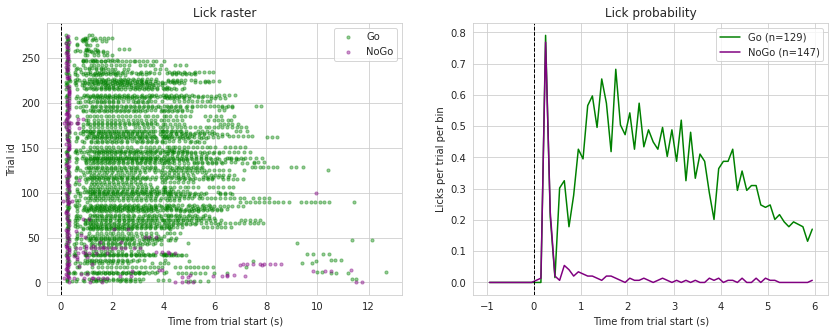

In [42]:
if trials_df.empty:
    raise ValueError('Trials dataframe is empty; cannot plot lick raster/probability.')
if lick_df.empty:
    raise ValueError('Lick table is empty; cannot plot lick raster/probability.')
starts = trials_df[['trial_id', 'start_time_ms', 'trial_type']] if 'start_time_ms' in trials_df else None
if starts is None:
    raise KeyError('Trials missing start_time_ms.')
lick_joined = lick_df.merge(starts, on='trial_id', how='left')
def pick(col_base):
    """Choose merged column even if suffix added."""
    for suffix in ['', '_y', '_x']:
        candidate = f'{col_base}{suffix}'
        if candidate in lick_joined.columns:
            return candidate
    raise KeyError(col_base)

start_col = pick('start_time_ms')
trial_type_col = pick('trial_type')
lick_joined['time_from_trial_start_s'] = (lick_joined['lick_time_ms'] - lick_joined[start_col]) / 1000.0
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=False)
trial_types = ['Go', 'NoGo']
bins = np.linspace(-1, 6, 71)
centers = 0.5 * (bins[:-1] + bins[1:])
for ttype, color in zip(trial_types, ['green', 'purple']):
    subset = lick_joined[lick_joined[trial_type_col].str.lower() == ttype.lower()]
    if subset.empty:
        continue
    axes[0].scatter(subset['time_from_trial_start_s'], subset['trial_id'], c=color, alpha=0.4, s=10, label=ttype)
    counts, _ = np.histogram(subset['time_from_trial_start_s'], bins=bins)
    n_trials = max(1, subset['trial_id'].nunique())
    prob = counts / n_trials
    axes[1].plot(centers, prob, color=color, label=f'{ttype} (n={n_trials})')
axes[0].axvline(0, color='black', linestyle='--', linewidth=1)
axes[0].set_xlabel('Time from trial start (s)')
axes[0].set_ylabel('Trial id')
axes[0].set_title('Lick raster')
axes[0].legend()
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_xlabel('Time from trial start (s)')
axes[1].set_ylabel('Licks per trial per bin')
axes[1].set_title('Lick probability')
axes[1].legend()
plt.show()


## First-lick latency vs trial number (Go/NoGo)


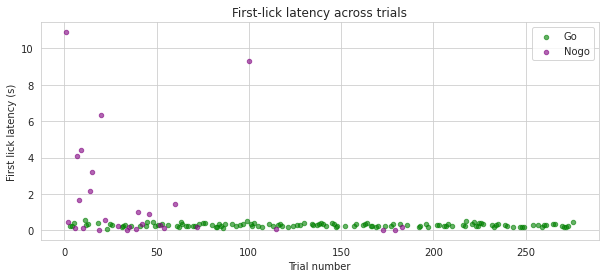

In [43]:
if trials_df.empty:
    raise ValueError('Trials dataframe is empty; cannot plot first-lick latency.')
trials_latency = trials_df.dropna(subset=['reaction_time_s']).copy()
if trials_latency.empty:
    raise ValueError('No reaction_time_s values available for latency plot.')
fig, ax = plt.subplots(figsize=(10, 4))
colors = {'go': 'green', 'nogo': 'purple'}
for ttype, color in colors.items():
    sub = trials_latency[trials_latency['trial_type'].str.lower() == ttype]
    if sub.empty:
        continue
    ax.scatter(sub['trial_number'], sub['reaction_time_s'], color=color, alpha=0.6, s=20, label=ttype.capitalize())
ax.set_xlabel('Trial number')
ax.set_ylabel('First lick latency (s)')
ax.set_title('First-lick latency across trials')
ax.legend()
plt.show()


## Speed around trial start (Go/NoGo)


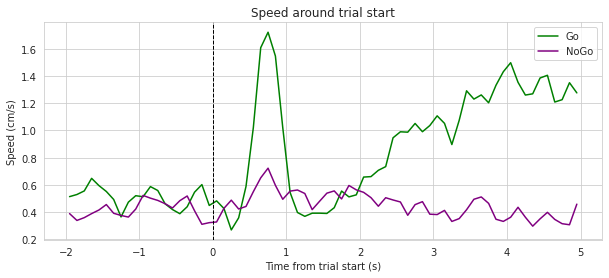

In [44]:
position_df = result.dataframes.get('Position')
if position_df is None or position_df.empty:
    raise ValueError('Position dataframe is empty; cannot compute speed.')
if trials_df.empty:
    raise ValueError('Trials dataframe is empty; cannot align speed to trials.')
pos = position_df.sort_values('time').copy()
pos['dt_s'] = pos['time'].diff() / 1000.0
pos['dx_cm'] = pos['position'].diff() / 100.0
pos['speed_cm_s'] = pos['dx_cm'] / pos['dt_s']
pos = pos.replace([np.inf, -np.inf], np.nan).dropna(subset=['speed_cm_s'])
window = (-2.0, 5.0)
segments = []
for _, trow in trials_df.iterrows():
    start_ms = trow.get('start_time_ms')
    if pd.isna(start_ms):
        continue
    mask = (pos['time'] >= start_ms + window[0]*1000) & (pos['time'] <= start_ms + window[1]*1000)
    seg = pos.loc[mask, ['time', 'speed_cm_s']].copy()
    if seg.empty:
        continue
    seg['rel_time_s'] = (seg['time'] - start_ms) / 1000.0
    seg['trial_type'] = trow.get('trial_type')
    segments.append(seg[['rel_time_s', 'speed_cm_s', 'trial_type']])
if not segments:
    raise ValueError('No speed segments found around trial starts.')
speed_df = pd.concat(segments, ignore_index=True).dropna()
bins = np.linspace(window[0], window[1], 71)
centers = 0.5 * (bins[:-1] + bins[1:])
fig, ax = plt.subplots(figsize=(10, 4))
for ttype, color in {'Go': 'green', 'NoGo': 'purple'}.items():
    sub = speed_df[speed_df['trial_type'].str.lower() == ttype.lower()]
    if sub.empty:
        continue
    sub = sub.copy()
    sub['bin'] = pd.cut(sub['rel_time_s'], bins=bins, labels=centers)
    agg = sub.groupby('bin')['speed_cm_s'].mean().reset_index()
    ax.plot(agg['bin'].astype(float), agg['speed_cm_s'], label=ttype, color=color)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Time from trial start (s)')
ax.set_ylabel('Speed (cm/s)')
ax.set_title('Speed around trial start')
ax.legend()
plt.show()


In [1]:
contents = list_hdf5_contents(str(result.output_h5))
print(contents)


NameError: name 'list_hdf5_contents' is not defined